# Modelo Causal v9 — DAG Formal (Directed Acyclic Graph)

**Objetivo 2 do TCC:** Construir um modelo causal por meio da abordagem de grafos causais (DAGs).

## O que é um DAG?

Um DAG (Directed Acyclic Graph) é um grafo direcionado sem ciclos que representa as relações causais entre variáveis. Cada aresta `A → B` significa *"A causa B"*.

No contexto de inferência causal, o DAG serve para:
1. **Identificar confundidores** — variáveis que precisam ser controladas
2. **Identificar colliders** — variáveis que NÃO devem ser controladas
3. **Verificar identificabilidade causal** — se é possível estimar o efeito de T sobre Y
4. **Justificar o conjunto de ajuste** — quais variáveis entram no IPTW

## Estrutura do notebook

1. DAG geral — todas as variáveis
2. DAG por tratamento — com critério de backdoor
3. Formalização via `dowhy`
4. Verificação de identificabilidade

## 1. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from dowhy import CausalModel
from app.config.settings import INTERIM_DATA_DIR

import warnings
warnings.filterwarnings('ignore')

/Users/andreza/Documents/GitHub/TCC-CEDS-CAUSAL-AI/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Justificativa das arestas causais

Cada aresta do DAG precisa de justificativa teórica ou operacional.

### Confundidores → Tratamento

| Aresta | Justificativa |
|---|---|
| `customer_state → despacho_lento` | Regiões remotas têm menos entregador disponíveis, aumentando tempo de despacho |
| `customer_state → aprovacao_lenta` | Estados com menor cobertura bancária têm mais transações que precisam de revisão manual |
| `avg_weight → despacho_lento` | Produtos pesados exigem logística especial, demorando mais para despacho |
| `avg_weight → aprovacao_lenta` | Produtos de alto valor (correlacionado com peso) têm maior chance de revisão de fraude |
| `total_price → aprovacao_lenta` | Compras de alto valor têm maior chance de análise antifraude |
| `total_price → pedido_grande` | Pedidos maiores tendem a ter valor total maior |
| `purchase_hour → aprovacao_lenta` | Compras fora do horário comercial são aprovadas só no dia seguinte |
| `purchase_weekday → aprovacao_lenta` | Compras em finais de semana têm aprovação pode levar mais tempo para aprovar??????? |
| `purchase_weekday → despacho_lento` | Pedidos feitos próximos ao fim de semana demoram mais para despacho |
| `purchase_month → despacho_lento` | Meses de alta demanda (ex: Black Friday) sobrecarregam a logística |
| `n_items_missing_info → despacho_lento` | Itens sem dimensões/peso causam retrabalho operacional |
| `n_items → pedido_grande` | `pedido_grande = (n_items > 1)` — relação definitória |

### Confundidores → Outcome

| Aresta | Justificativa |
|---|---|
| `customer_state → entrega_atrasada` | Distância do centro de distribuição afeta prazo de entrega |
| `customer_state → review_positivo` | Expectativas e experiências variam por região |
| `avg_weight → entrega_atrasada` | Produtos pesados têm logística de última milha mais lenta |
| `total_price → review_positivo` | Compras de maior valor têm expectativa mais alta |
| `purchase_month → entrega_atrasada` | Picos sazonais sobrecarregam transportadoras |

### Tratamento → Outcome

| Aresta | Justificativa |
|---|---|
| `despacho_lento → entrega_atrasada` | Despacho tardio propaga atraso para todo o ciclo de entrega |
| `despacho_lento → review_positivo` | Cliente percebe demora no despacho tende a penaliza atrasos no despacho no momento da avaliação final |
| `aprovacao_lenta → entrega_atrasada` | Aprovação tarde atrasa o início do ciclo operacional |
| `aprovacao_lenta → review_positivo` | Espera pela aprovação gera ansiedade no cliente |
| `pedido_grande → entrega_atrasada` | Pedidos com mais itens têm logística mais complexa |
| `pedido_grande → review_positivo` | Maior chance de ao menos 1 item gerar insatisfação |

## 3. DAG geral — todas as variáveis

In [2]:
# Definição das arestas do DAG geral
ARESTAS = [
    # Confundidores → Tratamentos
    ("customer_state",      "despacho_lento"),
    ("customer_state",      "aprovacao_lenta"),
    ("avg_weight",          "despacho_lento"),
    ("avg_weight",          "aprovacao_lenta"),
    ("total_price",         "aprovacao_lenta"),
    ("total_price",         "pedido_grande"),
    ("purchase_hour",       "aprovacao_lenta"),
    ("purchase_weekday",    "aprovacao_lenta"),
    ("purchase_weekday",    "despacho_lento"),
    ("purchase_month",      "despacho_lento"),
    ("n_items_missing_info","despacho_lento"),
    ("avg_price",           "pedido_grande"),

    # Confundidores → Outcomes
    ("customer_state",      "entrega_atrasada"),
    ("customer_state",      "review_positivo"),
    ("avg_weight",          "entrega_atrasada"),
    ("total_price",         "review_positivo"),
    ("purchase_month",      "entrega_atrasada"),
    ("purchase_month",      "review_positivo"),

    # Tratamentos → Outcomes
    ("despacho_lento",      "entrega_atrasada"),
    ("despacho_lento",      "review_positivo"),
    ("aprovacao_lenta",     "entrega_atrasada"),
    ("aprovacao_lenta",     "review_positivo"),
    ("pedido_grande",       "entrega_atrasada"),
    ("pedido_grande",       "review_positivo"),

    # Mediação: despacho_lento → entrega_atrasada → review_positivo
    ("entrega_atrasada",    "review_positivo"),
]

# Categorias de nós
CONFUNDIDORES = ["customer_state", "avg_weight", "total_price", "avg_price",
                 "purchase_hour", "purchase_weekday", "purchase_month",
                 "n_items_missing_info"]
TRATAMENTOS   = ["despacho_lento", "aprovacao_lenta", "pedido_grande"]
OUTCOMES      = ["entrega_atrasada", "review_positivo"]

print(f"Total de arestas: {len(ARESTAS)}")
print(f"Confundidores: {len(CONFUNDIDORES)}")
print(f"Tratamentos:   {len(TRATAMENTOS)}")
print(f"Outcomes:      {len(OUTCOMES)}")

Total de arestas: 25
Confundidores: 8
Tratamentos:   3
Outcomes:      2


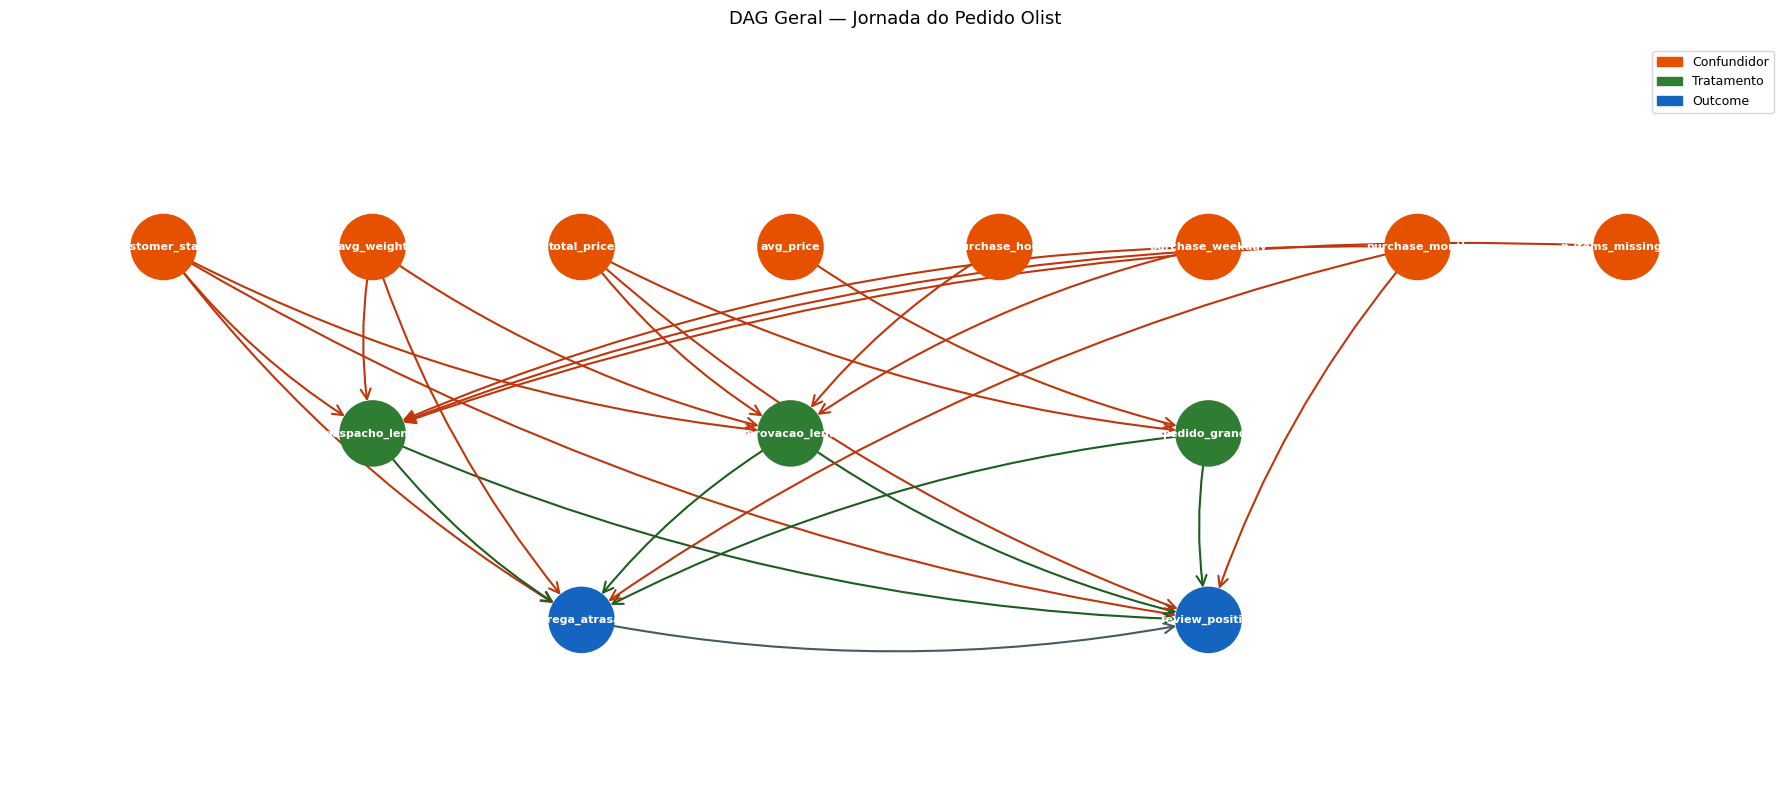

In [3]:
def plot_dag(arestas, confundidores, tratamentos, outcomes,
             titulo="DAG Causal", figsize=(16, 10), destaque_t=None, destaque_o=None):
    """
    Plota o DAG com layout em camadas:
      Camada 1 (topo): confundidores
      Camada 2 (meio): tratamentos
      Camada 3 (base): outcomes
    """
    G = nx.DiGraph()
    G.add_edges_from(arestas)

    # Layout em camadas
    pos = {}
    n_conf = len(confundidores)
    for i, n in enumerate(confundidores):
        pos[n] = (i * 2.0, 2)
    for i, n in enumerate(tratamentos):
        pos[n] = (i * 4.0 + 2, 1)
    for i, n in enumerate(outcomes):
        pos[n] = (i * 6.0 + 4, 0)

    # Cores dos nós
    cor_map = {}
    for n in G.nodes():
        if n in outcomes:
            cor_map[n] = "#1565c0"
        elif n in tratamentos:
            cor_map[n] = "#2e7d32" if destaque_t is None or n == destaque_t else "#a5d6a7"
        else:
            cor_map[n] = "#e65100"

    # Destaque do outcome
    if destaque_o:
        for n in outcomes:
            if n != destaque_o:
                cor_map[n] = "#90caf9"

    cores = [cor_map.get(n, "gray") for n in G.nodes()]

    # Cores das arestas
    edge_colors = []
    for u, v in G.edges():
        if u in tratamentos and v in outcomes:
            edge_colors.append("#1b5e20")
        elif u in confundidores:
            edge_colors.append("#bf360c")
        else:
            edge_colors.append("#455a64")

    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx(
        G, pos=pos, ax=ax,
        node_color=cores, node_size=2200,
        font_size=8, font_color="white", font_weight="bold",
        edge_color=edge_colors, arrows=True,
        arrowsize=18, arrowstyle="->",
        connectionstyle="arc3,rad=0.1",
        width=1.5
    )

    # Legenda
    legend = [
        mpatches.Patch(color="#e65100", label="Confundidor"),
        mpatches.Patch(color="#2e7d32", label="Tratamento"),
        mpatches.Patch(color="#1565c0", label="Outcome"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=9)
    ax.set_title(titulo, fontsize=13, pad=15)
    ax.axis("off")
    plt.tight_layout()
    return fig


fig = plot_dag(ARESTAS, CONFUNDIDORES, TRATAMENTOS, OUTCOMES,
               titulo="DAG Geral — Jornada do Pedido Olist", figsize=(18, 8))
plt.savefig("../../reports/figures/dag_geral.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. DAG por tratamento — critério de backdoor

O **critério de backdoor** diz que o conjunto de ajuste Z é válido se:
1. Nenhum nó em Z é descendente do tratamento T
2. Z bloqueia todos os caminhos de backdoor entre T e Y

Para cada tratamento, identificamos os **caminhos de backdoor** e o **conjunto de ajuste mínimo**.

DAG: despacho_lento
Conjunto de ajuste (backdoor): ['customer_state', 'avg_weight', 'purchase_weekday', 'purchase_month', 'n_items_missing_info']
Caminhos de backdoor bloqueados:
  despacho_lento ← customer_state → entrega_atrasada
  despacho_lento ← customer_state → review_positivo
  despacho_lento ← avg_weight → entrega_atrasada
  despacho_lento ← purchase_month → entrega_atrasada
  despacho_lento ← purchase_month → review_positivo


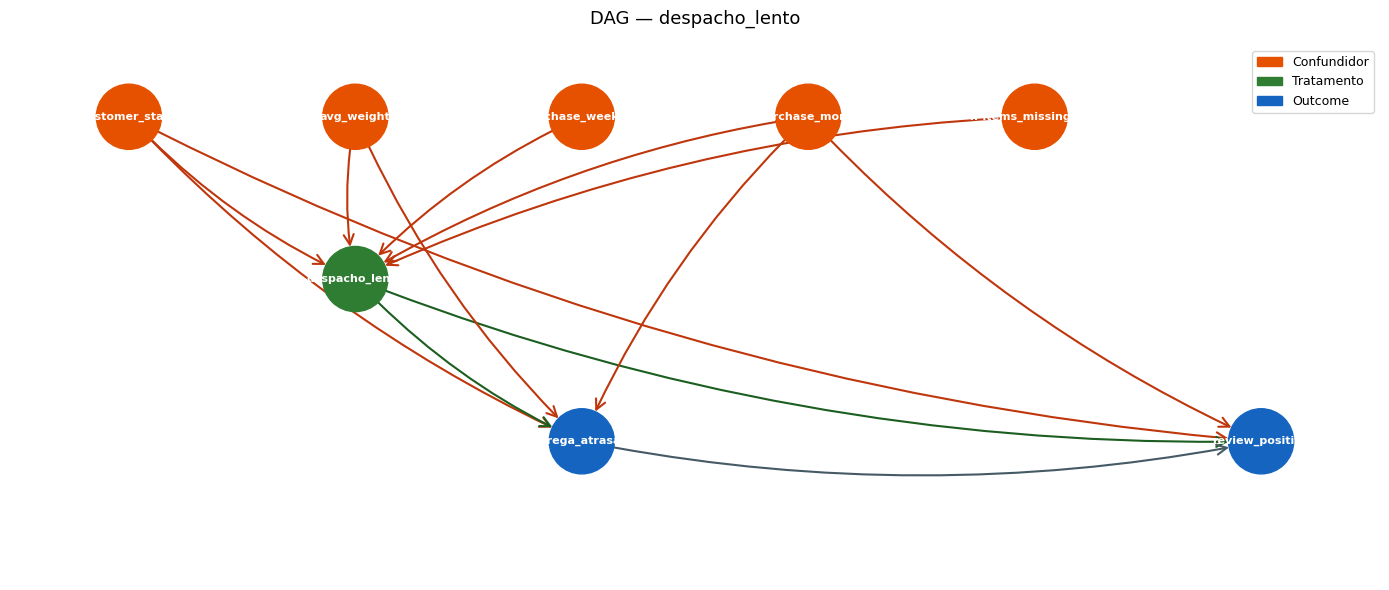

In [4]:
# DAG por tratamento — despacho_lento
ARESTAS_DESPACHO = [
    ("customer_state",      "despacho_lento"),
    ("avg_weight",          "despacho_lento"),
    ("purchase_weekday",    "despacho_lento"),
    ("purchase_month",      "despacho_lento"),
    ("n_items_missing_info","despacho_lento"),
    ("customer_state",      "entrega_atrasada"),
    ("customer_state",      "review_positivo"),
    ("avg_weight",          "entrega_atrasada"),
    ("purchase_month",      "entrega_atrasada"),
    ("purchase_month",      "review_positivo"),
    ("despacho_lento",      "entrega_atrasada"),
    ("despacho_lento",      "review_positivo"),
    ("entrega_atrasada",    "review_positivo"),
]

CONF_DESPACHO = ["customer_state", "avg_weight", "purchase_weekday",
                 "purchase_month", "n_items_missing_info"]

print("DAG: despacho_lento")
print(f"Conjunto de ajuste (backdoor): {CONF_DESPACHO}")
print("Caminhos de backdoor bloqueados:")
print("  despacho_lento ← customer_state → entrega_atrasada")
print("  despacho_lento ← customer_state → review_positivo")
print("  despacho_lento ← avg_weight → entrega_atrasada")
print("  despacho_lento ← purchase_month → entrega_atrasada")
print("  despacho_lento ← purchase_month → review_positivo")

fig = plot_dag(
    ARESTAS_DESPACHO,
    CONF_DESPACHO,
    ["despacho_lento"],
    ["entrega_atrasada", "review_positivo"],
    titulo="DAG — despacho_lento",
    figsize=(14, 6)
)
plt.savefig("../../reports/figures/dag_despacho_lento.png", dpi=150, bbox_inches="tight")
plt.show()

DAG: aprovacao_lenta
Conjunto de ajuste (backdoor): ['customer_state', 'avg_weight', 'total_price', 'purchase_hour', 'purchase_weekday', 'purchase_month']
Caminhos de backdoor bloqueados:
  aprovacao_lenta ← customer_state → entrega_atrasada
  aprovacao_lenta ← customer_state → review_positivo
  aprovacao_lenta ← total_price → review_positivo
  aprovacao_lenta ← purchase_weekday / purchase_hour (confundidores temporais)


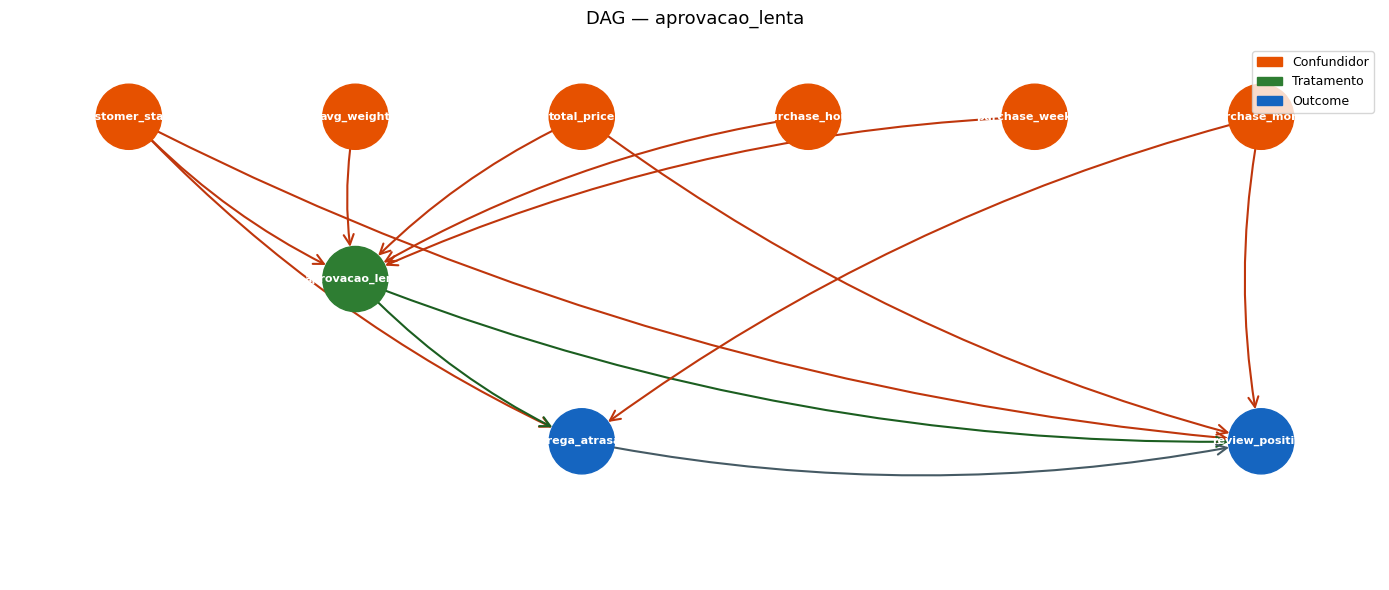

In [5]:
# DAG por tratamento — aprovacao_lenta
ARESTAS_APROVACAO = [
    ("customer_state",   "aprovacao_lenta"),
    ("avg_weight",       "aprovacao_lenta"),
    ("total_price",      "aprovacao_lenta"),
    ("purchase_hour",    "aprovacao_lenta"),
    ("purchase_weekday", "aprovacao_lenta"),
    ("customer_state",   "entrega_atrasada"),
    ("customer_state",   "review_positivo"),
    ("total_price",      "review_positivo"),
    ("purchase_month",   "entrega_atrasada"),
    ("purchase_month",   "review_positivo"),
    ("aprovacao_lenta",  "entrega_atrasada"),
    ("aprovacao_lenta",  "review_positivo"),
    ("entrega_atrasada", "review_positivo"),
]

CONF_APROVACAO = ["customer_state", "avg_weight", "total_price",
                  "purchase_hour", "purchase_weekday", "purchase_month"]

print("DAG: aprovacao_lenta")
print(f"Conjunto de ajuste (backdoor): {CONF_APROVACAO}")
print("Caminhos de backdoor bloqueados:")
print("  aprovacao_lenta ← customer_state → entrega_atrasada")
print("  aprovacao_lenta ← customer_state → review_positivo")
print("  aprovacao_lenta ← total_price → review_positivo")
print("  aprovacao_lenta ← purchase_weekday / purchase_hour (confundidores temporais)")

fig = plot_dag(
    ARESTAS_APROVACAO,
    CONF_APROVACAO,
    ["aprovacao_lenta"],
    ["entrega_atrasada", "review_positivo"],
    titulo="DAG — aprovacao_lenta",
    figsize=(14, 6)
)
plt.savefig("../../reports/figures/dag_aprovacao_lenta.png", dpi=150, bbox_inches="tight")
plt.show()

DAG: pedido_grande
Conjunto de ajuste (backdoor): ['total_price', 'avg_weight', 'avg_price', 'customer_state', 'purchase_month']
Observacao: n_items REMOVIDO — e a base do tratamento (pedido_grande = n_items > 1)
Caminhos de backdoor bloqueados:
  pedido_grande ← total_price → review_positivo
  pedido_grande ← avg_weight → entrega_atrasada


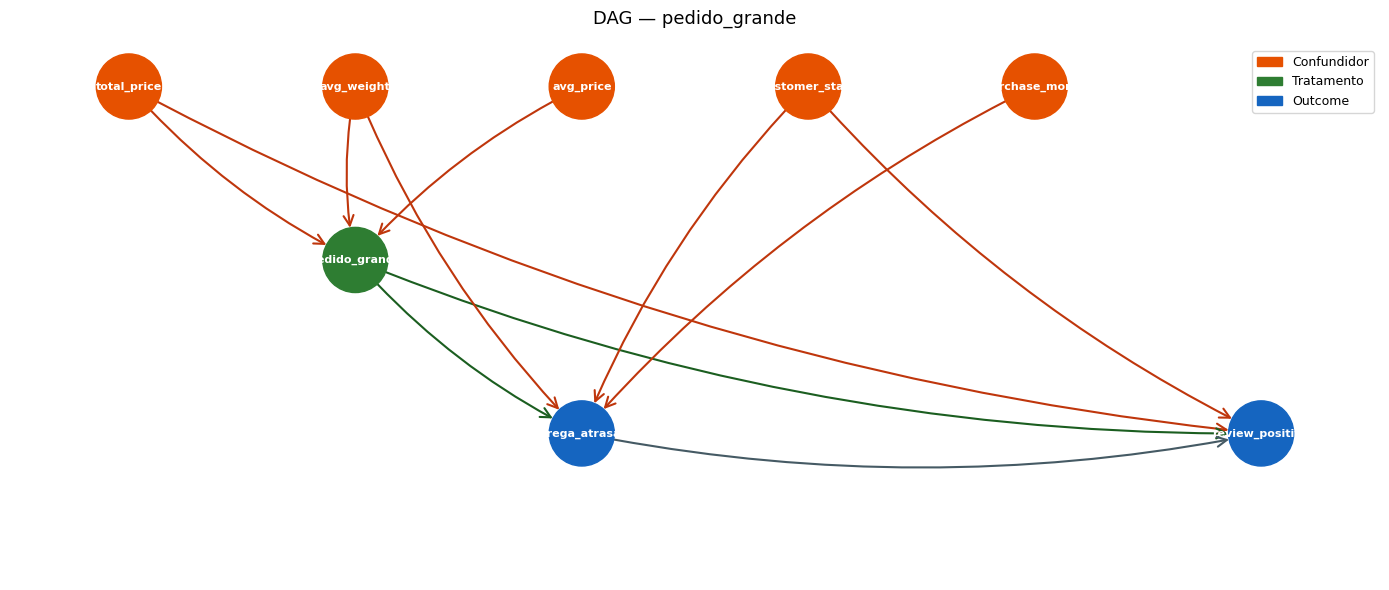

In [6]:
# DAG por tratamento — pedido_grande
ARESTAS_PEDIDO = [
    ("total_price",      "pedido_grande"),
    ("avg_weight",       "pedido_grande"),
    ("avg_price",        "pedido_grande"),
    ("customer_state",   "entrega_atrasada"),
    ("customer_state",   "review_positivo"),
    ("total_price",      "review_positivo"),
    ("avg_weight",       "entrega_atrasada"),
    ("purchase_month",   "entrega_atrasada"),
    ("pedido_grande",    "entrega_atrasada"),
    ("pedido_grande",    "review_positivo"),
    ("entrega_atrasada", "review_positivo"),
]

CONF_PEDIDO = ["total_price", "avg_weight", "avg_price",
               "customer_state", "purchase_month"]

print("DAG: pedido_grande")
print(f"Conjunto de ajuste (backdoor): {CONF_PEDIDO}")
print("Observacao: n_items REMOVIDO — e a base do tratamento (pedido_grande = n_items > 1)")
print("Caminhos de backdoor bloqueados:")
print("  pedido_grande ← total_price → review_positivo")
print("  pedido_grande ← avg_weight → entrega_atrasada")

fig = plot_dag(
    ARESTAS_PEDIDO,
    CONF_PEDIDO,
    ["pedido_grande"],
    ["entrega_atrasada", "review_positivo"],
    titulo="DAG — pedido_grande",
    figsize=(14, 6)
)
plt.savefig("../../reports/figures/dag_pedido_grande.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Formalização via DoWhy

O `dowhy` recebe o DAG em formato GML e verifica:
- Se o efeito causal é **identificável**
- Qual o **estimando causal** (expressão matemática do efeito)
- Quais variáveis compõem o conjunto de ajuste backdoor

In [7]:
df = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, "interim_dataset.parquet"))

for col in ["order_approved_at", "order_delivered_carrier_date",
            "order_delivered_customer_date", "order_estimated_delivery_date",
            "order_purchase_timestamp"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["approval_time_hours"] = (
    df["order_approved_at"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 3600
df["dispatch_time_days"]  = (
    df["order_delivered_carrier_date"] - df["order_approved_at"]
).dt.days
df["delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

df["despacho_lento"]   = (df["dispatch_time_days"] > 3).astype(int)
df["aprovacao_lenta"]  = (df["approval_time_hours"] > 24).astype(int)
df["pedido_grande"]    = (df["n_items"] > 1).astype(int)
df["entrega_atrasada"] = (df["delay_days"] > 0).astype(int)
df["review_positivo"]  = (df["review_score"] >= 4).astype(int)

from sklearn.preprocessing import LabelEncoder
df["customer_state"] = LabelEncoder().fit_transform(df["customer_state"])

print(f"Shape: {df.shape}")

Shape: (97712, 44)


In [8]:
def build_gml(treatment, outcome, confundidores, arestas_extras=None):
    """Gera string GML do DAG para uso no DoWhy."""
    nos = set([treatment, outcome] + confundidores)
    linhas = [f'    {t} -> {o};' for t, o in
              [(treatment, outcome)] +
              [(c, treatment) for c in confundidores] +
              [(c, outcome)   for c in confundidores] +
              (arestas_extras or [])]
    return "digraph {\n" + "\n".join(linhas) + "\n}"


def run_dowhy(df, treatment, outcome, confundidores, arestas_extras=None):
    cols = [treatment, outcome] + confundidores
    df_m = df[cols].dropna()

    gml = build_gml(treatment, outcome, confundidores, arestas_extras)

    model = CausalModel(
        data=df_m,
        treatment=treatment,
        outcome=outcome,
        graph=gml
    )

    identificado = model.identify_effect(proceed_when_unidentifiable=True)

    print(f"\n{'='*55}")
    print(f"DoWhy: {treatment} → {outcome}")
    print(f"{'='*55}")
    print(f"Identificavel: {identificado.estimands}")

    return model, identificado

In [9]:
# DoWhy — despacho_lento → entrega_atrasada
CONF_DESPACHO_IPTW = [
    "total_price", "n_items", "avg_weight",
    "customer_state", "purchase_month",
    "purchase_weekday", "purchase_hour", "n_items_missing_info"
]

model_d1, id_d1 = run_dowhy(
    df, "despacho_lento", "entrega_atrasada", CONF_DESPACHO_IPTW
)


DoWhy: despacho_lento → entrega_atrasada
Identificavel: {'backdoor1': {'estimand': Derivative(Expectation(entrega_atrasada|total_price,avg_weight,purchase_hour,n_items,customer_state,purchase_weekday,purchase_month,n_items_missing_info), [despacho_lento]), 'assumptions': {'Unconfoundedness': 'If U→{despacho_lento} and U→entrega_atrasada then P(entrega_atrasada|despacho_lento,total_price,avg_weight,purchase_hour,n_items,customer_state,purchase_weekday,purchase_month,n_items_missing_info,U) = P(entrega_atrasada|despacho_lento,total_price,avg_weight,purchase_hour,n_items,customer_state,purchase_weekday,purchase_month,n_items_missing_info)'}}, 'backdoor2': {'estimand': Derivative(Expectation(entrega_atrasada|total_price,avg_weight,purchase_hour,n_items,customer_state,purchase_weekday,purchase_month,n_items_missing_info), [despacho_lento]), 'assumptions': {'Unconfoundedness': 'If U→{despacho_lento} and U→entrega_atrasada then P(entrega_atrasada|despacho_lento,total_price,avg_weight,purchas

In [10]:
# DoWhy — despacho_lento → review_positivo
model_d2, id_d2 = run_dowhy(
    df, "despacho_lento", "review_positivo", CONF_DESPACHO_IPTW
)


DoWhy: despacho_lento → review_positivo
Identificavel: {'backdoor1': {'estimand': Derivative(Expectation(review_positivo|total_price,avg_weight,purchase_hour,n_items,customer_state,purchase_weekday,purchase_month,n_items_missing_info), [despacho_lento]), 'assumptions': {'Unconfoundedness': 'If U→{despacho_lento} and U→review_positivo then P(review_positivo|despacho_lento,total_price,avg_weight,purchase_hour,n_items,customer_state,purchase_weekday,purchase_month,n_items_missing_info,U) = P(review_positivo|despacho_lento,total_price,avg_weight,purchase_hour,n_items,customer_state,purchase_weekday,purchase_month,n_items_missing_info)'}}, 'backdoor2': {'estimand': Derivative(Expectation(review_positivo|total_price,avg_weight,purchase_hour,n_items,customer_state,purchase_weekday,purchase_month,n_items_missing_info), [despacho_lento]), 'assumptions': {'Unconfoundedness': 'If U→{despacho_lento} and U→review_positivo then P(review_positivo|despacho_lento,total_price,avg_weight,purchase_hour,n

In [11]:
# DoWhy — aprovacao_lenta → entrega_atrasada
CONF_APROVACAO_IPTW = [
    "total_price", "n_items", "avg_weight",
    "customer_state", "purchase_month",
    "purchase_weekday", "purchase_hour", "n_items_missing_info"
]

model_a1, id_a1 = run_dowhy(
    df, "aprovacao_lenta", "entrega_atrasada", CONF_APROVACAO_IPTW
)


DoWhy: aprovacao_lenta → entrega_atrasada
Identificavel: {'backdoor1': {'estimand': Derivative(Expectation(entrega_atrasada|total_price,avg_weight,purchase_hour,n_items,customer_state,purchase_weekday,purchase_month,n_items_missing_info), [aprovacao_lenta]), 'assumptions': {'Unconfoundedness': 'If U→{aprovacao_lenta} and U→entrega_atrasada then P(entrega_atrasada|aprovacao_lenta,total_price,avg_weight,purchase_hour,n_items,customer_state,purchase_weekday,purchase_month,n_items_missing_info,U) = P(entrega_atrasada|aprovacao_lenta,total_price,avg_weight,purchase_hour,n_items,customer_state,purchase_weekday,purchase_month,n_items_missing_info)'}}, 'backdoor2': {'estimand': Derivative(Expectation(entrega_atrasada|total_price,avg_weight,purchase_hour,n_items,customer_state,purchase_weekday,purchase_month,n_items_missing_info), [aprovacao_lenta]), 'assumptions': {'Unconfoundedness': 'If U→{aprovacao_lenta} and U→entrega_atrasada then P(entrega_atrasada|aprovacao_lenta,total_price,avg_weight

In [12]:
# DoWhy — pedido_grande → review_positivo
CONF_PEDIDO_IPTW = [
    "total_price", "avg_weight",
    "customer_state", "purchase_month",
    "purchase_weekday", "purchase_hour", "n_items_missing_info"
]

model_p1, id_p1 = run_dowhy(
    df, "pedido_grande", "review_positivo", CONF_PEDIDO_IPTW
)


DoWhy: pedido_grande → review_positivo
Identificavel: {'backdoor1': {'estimand': Derivative(Expectation(review_positivo|total_price,avg_weight,purchase_hour,purchase_weekday,customer_state,purchase_month,n_items_missing_info), [pedido_grande]), 'assumptions': {'Unconfoundedness': 'If U→{pedido_grande} and U→review_positivo then P(review_positivo|pedido_grande,total_price,avg_weight,purchase_hour,purchase_weekday,customer_state,purchase_month,n_items_missing_info,U) = P(review_positivo|pedido_grande,total_price,avg_weight,purchase_hour,purchase_weekday,customer_state,purchase_month,n_items_missing_info)'}}, 'backdoor2': {'estimand': Derivative(Expectation(review_positivo|total_price,avg_weight,purchase_hour,purchase_weekday,customer_state,purchase_month,n_items_missing_info), [pedido_grande]), 'assumptions': {'Unconfoundedness': 'If U→{pedido_grande} and U→review_positivo then P(review_positivo|pedido_grande,total_price,avg_weight,purchase_hour,purchase_weekday,customer_state,purchase_

## 6. Resumo — Conjuntos de ajuste por tratamento

Tabela consolidando os conjuntos de ajuste (backdoor) validados pelo DAG e usados no IPTW.

In [13]:
resumo = [
    {
        "Tratamento":        "despacho_lento",
        "Outcomes":          "entrega_atrasada, review_positivo",
        "Conjunto de ajuste": "total_price, n_items, avg_weight, customer_state, "
                              "purchase_month, purchase_weekday, purchase_hour, n_items_missing_info",
        "Notebook IPTW":     "v6",
        "Balanço SMD":       "✅ Todos < 0.1"
    },
    {
        "Tratamento":        "aprovacao_lenta",
        "Outcomes":          "entrega_atrasada, review_positivo",
        "Conjunto de ajuste": "total_price, n_items, avg_weight, customer_state, "
                              "purchase_month, purchase_weekday, purchase_hour, n_items_missing_info",
        "Notebook IPTW":     "v6",
        "Balanço SMD":       "✅ Todos < 0.1"
    },
    {
        "Tratamento":        "pedido_grande",
        "Outcomes":          "entrega_atrasada, review_positivo",
        "Conjunto de ajuste": "total_price, avg_weight, customer_state, "
                              "purchase_month, purchase_weekday, purchase_hour, n_items_missing_info"
                              "(n_items removido — base do tratamento)",
        "Notebook IPTW":     "v7",
        "Balanço SMD":       "⚠️ total_price SMD=0.18"
    },
]

df_resumo = pd.DataFrame(resumo)
print(df_resumo.to_string(index=False))

     Tratamento                          Outcomes                                                                                                                                    Conjunto de ajuste Notebook IPTW             Balanço SMD
 despacho_lento entrega_atrasada, review_positivo                               total_price, n_items, avg_weight, customer_state, purchase_month, purchase_weekday, purchase_hour, n_items_missing_info            v6           ✅ Todos < 0.1
aprovacao_lenta entrega_atrasada, review_positivo                               total_price, n_items, avg_weight, customer_state, purchase_month, purchase_weekday, purchase_hour, n_items_missing_info            v6           ✅ Todos < 0.1
  pedido_grande entrega_atrasada, review_positivo total_price, avg_weight, customer_state, purchase_month, purchase_weekday, purchase_hour, n_items_missing_info(n_items removido — base do tratamento)            v7 ⚠️ total_price SMD=0.18


## Análise dos resultados — Notebook 09 DAG

---

### O que o DoWhy confirmou

Todos os 4 efeitos causais são identificáveis via critério de backdoor. O estimando retornado em todos os casos é:

∂E[outcome | confundidores] / ∂tratamento

Isso significa: "condicionar nos confundidores é suficiente para identificar o efeito causal" — que é exatamente o que o IPTW faz.

---

### A suposição central 

O DoWhy deixou explícita a única suposição necessária para cada análise:

> "Se existe uma variável não observada U que afeta tanto o tratamento quanto o outcome, então o efeito NÃO está identificado"

Assumi que não há confundidores escondidos além dos que estão no conjunto de ajuste. Isso é a suposição de ignorabilidade condicional, e ela não pode ser testada pelos dados — precisa ser justificada pela teoria 

---

### Análise 

| Análise                          | Identificável? | Conjunto de ajuste confirmado pelo DoWhy |
|----------------------------------|----------------|------------------------------------------|
| despacho_lento → entrega_atrasada |   backdoor     | total_price, avg_weight, purchase_hour, n_items, customer_state, purchase_weekday, purchase_month, n_items_missing_info |
| despacho_lento → review_positivo  |  backdoor     | idem |
| aprovacao_lenta → entrega_atrasada| backdoor     | idem |
| pedido_grande → review_positivo   | backdoor     | total_price, avg_weight, purchase_hour, purchase_weekday, customer_state, purchase_month, n_items_missing_info (sem n_items) |

---

### Ponto importante 

O DoWhy não encontrou instrumento (iv: None) nem frontdoor (frontdoor: None) — isso significa que o único caminho de identificação disponível é o backdoor, que depende da suposição de unconfoundedness. Isso deve ser mencionado como limitação no TCC:

> "A identificação causal depende da suposição de ausência de confundidores não observados. Variáveis como qualidade do seller, distância ao centro de distribuição ou condições climáticas na rota de entrega não estavam disponíveis no dataset e podem representar fontes de viés residual."

